In [ ]:
import kagglehub
kagglehub.login()


In [ ]:
vagheshjadav_master_dataset_path = kagglehub.dataset_download('vagheshjadav/master-dataset')
vagheshjadav_leaf_disease_mobilenetv3_trained_model_path = kagglehub.dataset_download('vagheshjadav/leaf-disease-mobilenetv3-trained-model')
vagheshjadav_plant_disease_concepts_path = kagglehub.dataset_download('vagheshjadav/plant-disease-concepts')

print('Data source import complete.')


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

MODEL_PATH = "/kaggle/input/leaf-disease-mobilenetv3-trained-model/Leaf_Disease_MobileNetV3_Final.keras" 

model = load_model(MODEL_PATH)
print("✅ Model loaded successfully")
model.summary()

2026-04-02 04:04:48.379680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775102688.574717      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775102688.634022      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775102689.105010      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775102689.105053      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775102689.105056      55 computation_placer.cc:177] computation placer alr

✅ Model loaded successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 6, 6, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │        10,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,716,055 (37.06 MB)

 Trainable params: 3,229,911 (12.32 MB)

 Non-trainable params: 26,320 (102.81 KB)

 Optimizer params: 6,459,824 (24.64 MB)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 192

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    return img

img = preprocess_image("/kaggle/input/master-dataset/Master_Dataset/val/Apple___Cedar_apple_rust/072f23fb-0b1a-43b9-a548-3981120ff33c___FREC_C.Rust 0133.JPG")

input_img = np.expand_dims(img, axis=0)

In [ ]:
preds = model.predict(input_img)
class_idx = np.argmax(preds)

print("Predicted class:", class_idx)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted class: 30


In [ ]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

last_conv_layer = "conv_1"
print("Using layer:", last_conv_layer)

Using layer: conv_1


In [ ]:
base_model = model.get_layer("MobileNetV3Large")

x = base_model.output
for layer in model.layers[2:]:   
    x = layer(x)

classifier_model = tf.keras.Model(inputs=base_model.input, outputs=x)

In [ ]:
def gradcam(img, class_idx):

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer("conv_1").output,  # last conv
            classifier_model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap

heatmap = gradcam(input_img, class_idx)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 192, 192, 3))
  warnings.warn(msg)


In [ ]:
heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

threshold = np.mean(heatmap_resized)
mask = heatmap_resized > threshold

gradcam_area = np.sum(mask) / mask.size

print("Disease Area %:", gradcam_area * 100)

Disease Area %: 21.156141493055554


In [ ]:
def extract_patches(image, patch_size=32):
    patches = []
    coords = []
    h, w, _ = image.shape

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
                patches.append(patch)
                coords.append((i, j))

    return np.array(patches), coords

patches, coords = extract_patches(img)

In [ ]:
#Feature Extraction
from tensorflow.keras.models import Model

base_model = model.get_layer("MobileNetV3Large")

feature_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.output
)

def get_features(patches):
    patches = np.array([cv2.resize(p, (192,192)) for p in patches])
    patches = patches.astype("float32") / 255.0   # ⚠️ important

    features = feature_model.predict(patches, verbose=0)
    features = features.reshape(features.shape[0], -1)

    return features

features = get_features(patches)

In [ ]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(features)

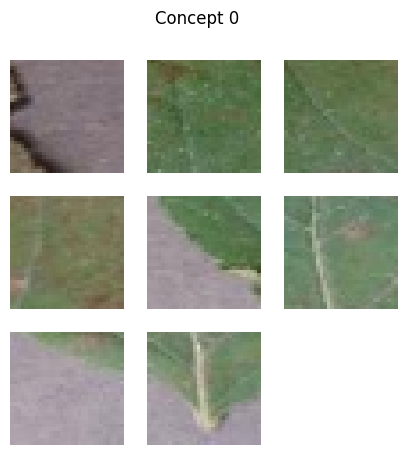

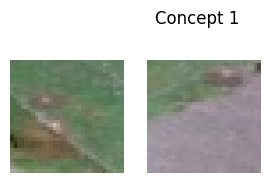

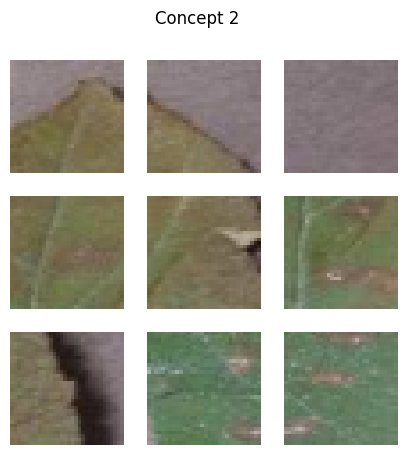

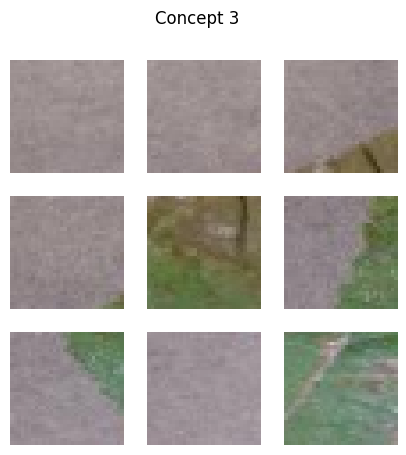

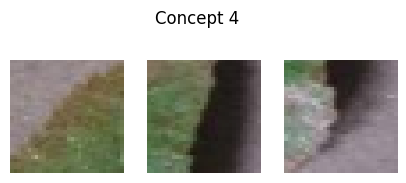

In [ ]:
for i in range(k):
    cluster_patches = patches[labels == i]

    plt.figure(figsize=(5,5))
    for j in range(min(9, len(cluster_patches))):
        plt.subplot(3,3,j+1)
        plt.imshow(cluster_patches[j])
        plt.axis("off")

    plt.suptitle(f"Concept {i}")
    plt.show()

In [ ]:
concept_names = {
    0: "Brown Spots",
    1: "Yellowing",
    2: "Healthy Texture",
    3: "Leaf Veins",
    4: "Background Noise"
}

In [ ]:
concept_importance = []

for i in range(k):
    idx = np.where(labels == i)[0]

    if len(idx) == 0:
        concept_importance.append(0)
        continue

    selected_patches = patches[idx]

    modified_img = img.copy()

    for id in idx:
        x, y = coords[id]
        modified_img[x:x+32, y:y+32] = 0

    modified_input = np.expand_dims(modified_img, axis=0)
    new_pred = model.predict(modified_input)[0][class_idx]

    importance = preds[0][class_idx] - new_pred
    concept_importance.append(abs(importance))

# Normalize
concept_importance = np.array(concept_importance)
concept_importance = concept_importance / (concept_importance.sum() + 1e-8)

print("Concept Importance:", concept_importance)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Concept Importance: [0.40279025 0.00473871 0.25589028 0.32381177 0.01263656]


In [ ]:
#Concept Area
concept_area = {i: 0 for i in range(k)}

for idx, (x, y) in enumerate(coords):
    concept_id = labels[idx]

    patch_mask = mask[x:x+32, y:y+32]
    area = np.sum(patch_mask) / (32 * 32)

    concept_area[concept_id] += area

print("Concept Areas:", concept_area)

Concept Areas: {0: np.float64(1.9697265625), 1: np.float64(0.427734375), 2: np.float64(3.6279296875), 3: np.float64(1.26953125), 4: np.float64(0.3212890625)}


In [ ]:
# 🔥 Normalize concept area
total_area = sum(concept_area.values()) + 1e-8

for i in concept_area:
    concept_area[i] /= total_area

In [ ]:
#Compute CWSI
CWSI = 0

for i in range(k):
    CWSI += concept_importance[i] * concept_area[i]

CWSI = np.clip(CWSI, 0, 1) * 100

print("CWSI (Severity %):", CWSI)

CWSI (Severity %): 28.083710732607486


In [ ]:
print("\nConcept Contributions:")

for i in range(k):
    contribution = concept_importance[i] * concept_area[i]
    print(f"{concept_names[i]} → {contribution*100:.2f}%")


🔍 Concept Contributions:
Brown Spots → 10.42%
Yellowing → 0.03%
Healthy Texture → 12.19%
Leaf Veins → 5.40%
Background Noise → 0.05%


In [ ]:
img_copy = img.copy()

for idx, (x, y) in enumerate(coords):
    concept_id = labels[idx]

    # Example: highlight disease-related concept
    if concept_names[concept_id] in ["Brown Spots", "Yellowing"]:
        cv2.rectangle(img_copy, (y, x), (y+32, x+32), (255,0,0), 1)

In [ ]:
#Severity Level
def get_severity(cwsi):
    if cwsi < 25:
        return "Mild"
    elif cwsi < 50:
        return "Moderate"
    elif cwsi < 75:
        return "Severe"
    else:
        return "Critical"

severity = get_severity(CWSI)
print("Severity:", severity)

Severity: Moderate


(np.float64(-0.5), np.float64(191.5), np.float64(191.5), np.float64(-0.5))

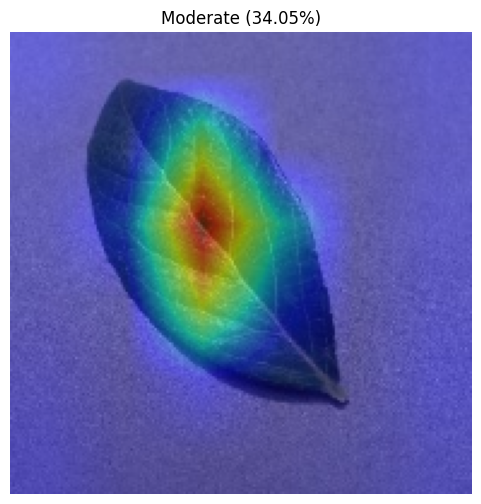

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
plt.title(f"{severity} ({CWSI:.2f}%)")
plt.axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(np.float64(-0.5), np.float64(191.5), np.float64(191.5), np.float64(-0.5))

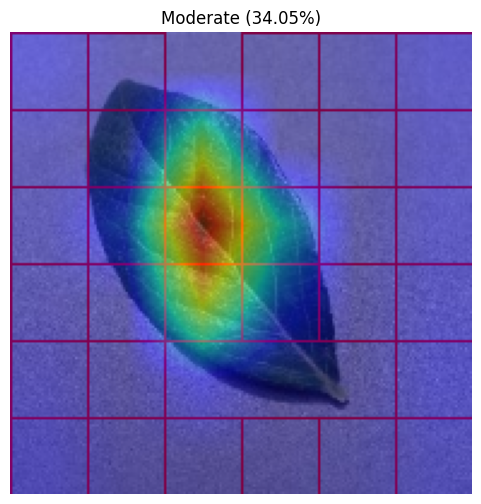

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img_copy)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
plt.title(f"{severity} ({CWSI:.2f}%)")
plt.axis("off")